In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd
import util
from jax import numpy as jnp
from importlib import reload

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

#### Loading Data-Table

In [2]:
tab = Table.read("C:/Users/Ruben/Desktop/All_candidates_200pc_noparallaxovererror.vot")

#### What subsample can be expected to be volume-complete?

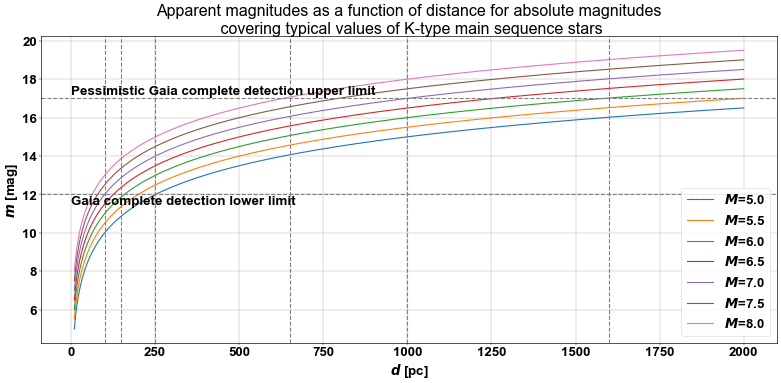

In [3]:
def M_d_to_m(M, d):
    '''Absolute magnitude M in mag, distance in pc, to apparent magnitude m in mag'''
    m = M + 5.*np.log10(d) - 5.
    return m

fig = plt.figure(figsize=(20,10))
Ms = np.linspace(5, 8, 7) # absolute magnitude in mag
dist = np.linspace(10, 2000, 1000) # pc
for M in Ms:
    m = M_d_to_m(M, dist)
    plt.plot(dist, m, label=r"$M$={:.2}".format(M))

plt.axhline(17.0, color="gray", ls="--")
plt.axhline(12.0, color="gray", ls="--")
plt.axvline(650, color="gray", ls="--")
plt.axvline(1000, color="gray", ls="--")
plt.axvline(1600, color="gray", ls="--")
plt.axvline(100, color="gray", ls="--")
plt.axvline(150, color="gray", ls="--")
plt.axvline(250, color="gray", ls="--")

plt.text(0, 17.2, "Pessimistic Gaia complete detection upper limit")
plt.text(0, 11.5, "Gaia complete detection lower limit")

plt.ylabel(r"$m$ [mag]")
plt.xlabel(r"$d$ [pc]")
plt.title("Apparent magnitudes as a function of distance for absolute magnitudes\n covering typical values of K-type main sequence stars")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("Plots/Distance_vs_apparent_magnitude.png")
fig.set_dpi(40)
plt.show()
# See also https://gea.esac.esa.int/archive/documentation/GDR3/Catalogue_consolidation/chap_cu9val/sec_cu9val_introduction/ssec_cu9val_intro_completeness.html
# and links therein
# Fig.14.38 suggests that most of the persumably missed stars originiate from a mismodelled disc and high latitudes are fine (-> perhaps we can go higher than 17 mag)
# Though, I would not trust this hope. Perhaps it would be best to split the dataset into two or three (e.g. like this):
    # M=5-6 and d<2000pc
    # M=6-8 and d<1000pc

    #safe intervals:    M=5-6, d=250-1600
    #                   M=6-7, d=150-1000
    #                   M=7-8, d=100-650


### z dependence of stars with inaccurate parallaxe measurment

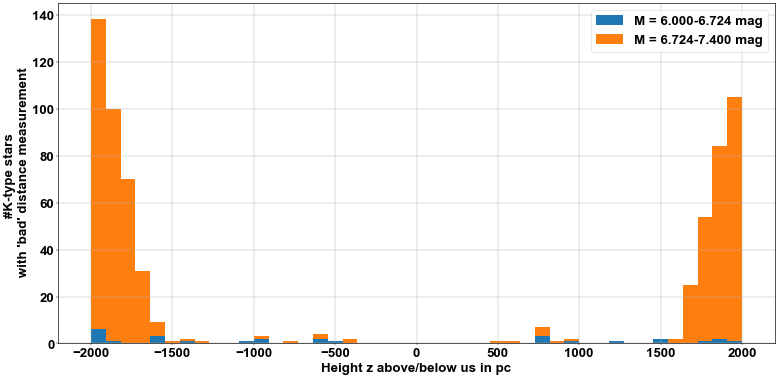

Requirement: parallax/standarterror(parallax) is larger than 3. This ensures useful parallax measurment. Removes an additional 2.22e+03 sources
We are left with 6.42e+05 sources
Requirement: Inside the cylinder of 2 * 1800.0 pc hight (centered at galactic plane!). Removes an additional 1.82e+03 sources
We are left with 6.41e+05 sources


In [13]:
# Distance
deg2rad = np.pi/180.
dist_pc = 1000./tab["parallax"] # in pc
# Absolute magnitude
apparent_magnitude = np.array(tab["phot_g_mean_mag"]) # 3.15 - 19.00
absolute_magnitude = apparent_magnitude - 5.*np.log10(dist_pc) + 5

parallax_over_error = np.array(tab["parallax"]/tab["parallax_error"])
min = 3
mask0 = parallax_over_error > min
group1 = (absolute_magnitude[~mask0] >= 6.000) & (absolute_magnitude[~mask0] < 6.724)
group2 = (absolute_magnitude[~mask0] >= 6.724) & (absolute_magnitude[~mask0] <= 7.400)
z_out = (dist_pc*np.sin(tab["b"]*deg2rad))[~mask0]
absolute_magnitude_out = absolute_magnitude[~mask0]

fig = plt.figure(figsize=(20,10))
plt.hist([z_out[group1], z_out[group2]], bins=44, stacked=True, range=(-2000, 2000), label=["M = 6.000-6.724 mag", "M = 6.724-7.400 mag"])
plt.xlabel("Height z above/below us in pc")
plt.ylabel("#K-type stars \n with 'bad' distance measurement")
plt.grid()
plt.tight_layout()
plt.legend()
plt.savefig("Plots/Height_distribution_bad_distance_measurement.png")
fig.set_dpi(40)
plt.show()

print("Requirement: parallax/standarterror(parallax) is larger than {}. This ensures useful parallax measurment. Removes an additional {:.2e} sources".format(min, np.nansum(~mask0)))
print("We are left with {:.2e} sources".format(np.nansum(mask0)))

# # Cylinder with radius r_cyl #obsolete
# r_cyl = 200. # pc # parallax > cos(lat)*5
# mask = dist_pc * np.cos(tab["b"]*deg2rad) < r_cyl # 200 pc cylinder 
# print("Requirement: Inside the cylinder of {} pc radius. Removes {:.2e} of {:.2e} sources".format(r_cyl, np.nansum(~mask), mask.size))
# print("We are left with {:.2e} sources".format(np.nansum(mask)))

# Cylinder symmetrical around galactic plane
height = 1800. # pc
mask1 = (dist_pc[mask0]*np.sin(tab["b"][mask0]*deg2rad)<height-14.5) & (dist_pc[mask0]*np.sin(tab["b"][mask0]*deg2rad)>-height-14.5)
print("Requirement: Inside the cylinder of 2 * {} pc hight (centered at galactic plane!). Removes an additional {:.2e} sources".format(height, np.nansum(~mask1)))
print("We are left with {:.2e} sources".format(np.nansum(mask1)))

#### Selecting a subsample

In [25]:
def filtration(am_min = 5.0, am_max = 8.0):
# make this smaller for better volume completeness (default 8.0)

    # Absolute magnitude limits
    mask2 = (absolute_magnitude[mask0][mask1]>=am_min) & (absolute_magnitude[mask0][mask1]<=am_max)
    print("Requirement: Absolute magnitude between {} and {}. Removes an additional {:.2e} sources".format(am_min, am_max, np.nansum(~mask2)))
    print("We are left with {:.2e} sources".format(np.nansum(mask2)))
    tab_filtered = tab[mask0][mask1][mask2]

    return tab_filtered

In [26]:
# Load into separate numpy arrays
def arrays(tab_filtered):
    np_arr = np.array(tab_filtered)

    l_np = np_arr["l"]
    b_np = np_arr["b"]
    ra_np = np_arr["ra"]
    ra_error_np = np_arr["ra_error"]
    dec_np = np_arr["dec"]
    dec_error_np = np_arr["dec_error"]
    parallax_np = np_arr["parallax"]
    parallax_error_np = np_arr["parallax_error"]
    pmra_np = np_arr["pmra"]
    pmra_error_np = np_arr["pmra_error"]
    pmdec_np = np_arr["pmdec"]
    pmdec_error_np = np_arr["pmdec_error"]
    phot_g_mean_mag_np = np_arr["phot_g_mean_mag"]
    teff_gspphot_np = np_arr["teff_gspphot"]
    bp_rp_np = np_arr["bp_rp"]
    radial_velocity_np = np_arr["radial_velocity"]
    radial_velocity_error_np = np_arr["radial_velocity_error"]

    del np_arr

    return l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np

# Vertical Distribution and Velocity Dispersion

In [27]:
###  Functions for computing the vertical velocity
def r_from_plx(plx):
    '''From parallax in mas to distance in pc'''
    return np.abs(1./np.tan(1e-3*plx))

def pm_eq_to_pm_gal(mu_alpha_cos_delta, mu_delta, alpha, delta):
    ''' In- and Output in degrees per arbitrary unit of time'''
    # from https://arxiv.org/pdf/1306.2945
    deg2rad = np.pi/180.
    deltaG = 27.12825 * deg2rad
    alphaG = 192.85948 * deg2rad
    _delta = delta * deg2rad
    _alpha = alpha * deg2rad
    C1 = np.sin(deltaG)*np.cos(_delta) - np.cos(deltaG)*np.sin(_delta)*np.cos(_alpha-alphaG)
    C2 = np.cos(deltaG)*np.sin(_alpha-alphaG)
    cos_b = np.sqrt(C1**2 + C2**2)
    mu_l_cos_b = (C1*mu_alpha_cos_delta + C2*mu_delta)/cos_b
    mu_b = (-C2*mu_alpha_cos_delta + C1*mu_delta)/cos_b
    return mu_l_cos_b, mu_b

def ra_dec_to_l_b(ra, dec):
    '''From ra and dec in degrees to l and b in degrees'''
    # See http://www.iausofa.org/2023_1011_C/sofa/icrs2g.c
    deg2rad = np.pi/180.
    deltaG = 27.12825 * deg2rad
    alphaG = 192.85948 * deg2rad
    l_ANGE = 32.93192 * deg2rad
    _ra = ra * deg2rad
    _dec = dec * deg2rad
    
    b = np.arcsin(np.cos(_dec)*np.cos(deltaG)*np.cos(_ra-alphaG)+np.sin(_dec)*np.sin(deltaG))
    x = np.sin(_ra-alphaG)*np.cos(_dec)
    y = np.sin(_dec)*np.cos(deltaG)-np.cos(_dec)*np.sin(deltaG)*np.cos(_ra-alphaG)
    
    l = np.arctan2(y, x) + l_ANGE
    l = np.mod(l, 2.*np.pi)
    
    return l/deg2rad, b/deg2rad

def compute_vz(plx, ra, dec, vlos, pm_ra, pm_dec,):
    """From 
    parallax in mas,
    ra and dec in degrees,
    vlos in km/s,
    pm_ra and pm_dec in mas/yr,
    to vz in km/s"""
    deg2rad = np.pi / 180.
    yr_to_sec = 3.154e7
    pc_to_km = 3.086e13
    mas_to_deg = 1./60./60./1000.
    _pm_ra = pm_ra * mas_to_deg # deg/yr
    _pm_dec = pm_dec * mas_to_deg # deg/yr
    
    pm_l, pm_b = pm_eq_to_pm_gal(_pm_ra, _pm_dec, ra, dec)  # deg/yr
    pm_l *=  deg2rad / yr_to_sec # rad/s
    pm_b *= deg2rad / yr_to_sec # rad/s

    l, b = ra_dec_to_l_b(ra, dec) # deg
    l *= deg2rad # rad
    b *= deg2rad # rad

    r = r_from_plx(plx) * pc_to_km  # km
    v_z = vlos * np.sin(b) + r * np.cos(b) * pm_b  # km/s
    
    return v_z

# Velocity Dispersion

Requirement: Absolute magnitude between 6.0 and 6.724. Removes an additional 4.61e+05 sources
We are left with 1.79e+05 sources
Mean vertical velocity =  -8.015793801123731 km/s
Mean squared deviation =  433.73291853352964
Std. dev. of squared deviation 953.2417009114425


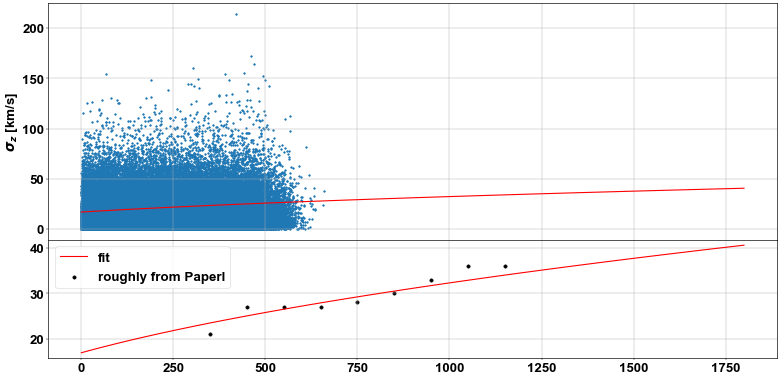

Requirement: Absolute magnitude between 6.724 and 7.4. Removes an additional 4.62e+05 sources
We are left with 1.79e+05 sources
Mean vertical velocity =  -7.8719518739069425 km/s
Mean squared deviation =  452.8065245315624
Std. dev. of squared deviation 1170.3368192848027


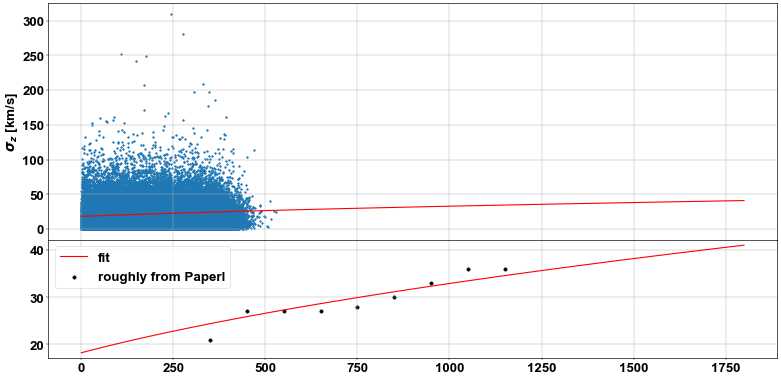

In [44]:
def poly_fit(am_min, am_max):
    tab_filtered = filtration(am_min, am_max)
    l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

    r_np = r_from_plx(parallax_np)
    z_np = r_np * np.sin(b_np*deg2rad) +14.5 #correction for height of the sun above the galactic plane

    # Compute vertical velocity dispersion
    vz = compute_vz(parallax_np, ra_np, dec_np, radial_velocity_np, pmra_np, pmdec_np)
    hasv = np.isfinite(vz) 
    vmean = np.mean(vz[hasv])
    print("Mean vertical velocity = ", vmean, "km/s")
    v2 = (vz[hasv]-vmean)**2
    print("Mean squared deviation = ", np.mean(v2))
    print("Std. dev. of squared deviation", np.sqrt(np.var(v2)))

    # Lets fit a simple curve
    POLYNOME_ORDER = 1
    v2_fit = np.poly1d(np.polyfit(np.abs(z_np)[hasv], v2, POLYNOME_ORDER))
    zs = np.linspace(0, 1800, 100)
    sigmas = np.sqrt(v2_fit(zs))

    z_vel = jnp.array([350, 450, 550, 650, 750, 850, 950, 1050, 1150])
    s_vel = jnp.array([21., 27., 27., 27., 28., 30., 33., 36., 36.])

    fig, ax = plt.subplots(2,1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [2,1]})
    ax[0].scatter(np.abs(z_np)[hasv], np.sqrt(v2), marker='.')
    ax[0].plot(zs, sigmas, color='r')
    ax[0].set_ylabel(r"$\sigma_z$ [km/s]")
    ax[0].grid()
    ax[1].plot(zs, sigmas, color='r', label='fit')
    ax[1].scatter(z_vel, s_vel, color='black', label='roughly from PaperI')
    ax[1].grid()
    ax[1].legend()
    plt.tight_layout()
    fig.subplots_adjust(hspace=0.0)
    fig.set_dpi(40)
    plt.show()

    df = pd.DataFrame({'z': z_np[hasv], 'v2': v2})

    # Create a text file
    df.to_csv(f'real data new intervals/v2_{am_min*1000:.0f}{am_max*1000:.0f}.txt', index=False, sep=',', header=True)
    np.savetxt(f'real data new intervals/poly_{am_min*1000:.0f}{am_max*1000:.0f}.txt', np.polyfit(np.abs(z_np)[hasv], v2, POLYNOME_ORDER), fmt='%f')

poly_fit(6.0, 6.724)
poly_fit(6.724, 7.4)

Requirement: Absolute magnitude between 6.0 and 6.724. Removes an additional 4.61e+05 sources
We are left with 1.79e+05 sources
Requirement: Absolute magnitude between 6.724 and 7.4. Removes an additional 4.62e+05 sources
We are left with 1.79e+05 sources


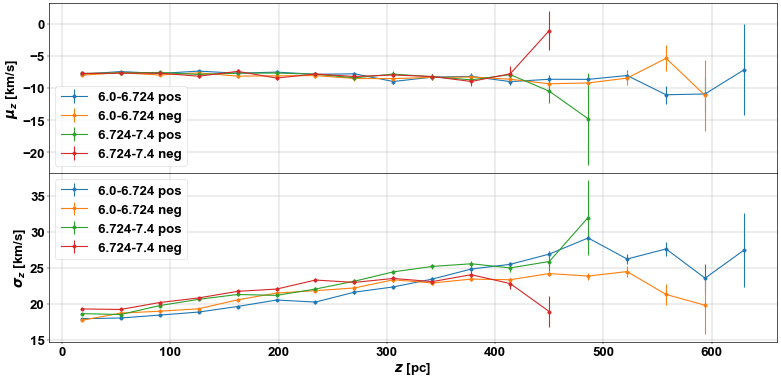

In [45]:
def vel_disp(am_min, am_max, n_bins):

    tab_filtered = filtration(am_min, am_max)
    l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

    r_np = r_from_plx(parallax_np)
    z_np = r_np * np.sin(b_np*deg2rad) +14.5 #correction for height of the sun above the galactic plane

    # Compute vertical velocity dispersion
    vz = compute_vz(parallax_np, ra_np, dec_np, radial_velocity_np, pmra_np, pmdec_np)
    hasv = np.isfinite(vz)
    vz = vz[hasv]
    z_np = z_np[hasv]

    bins = np.linspace(-1800, 1800, n_bins+1)
    vz_means = np.array([])
    vz_stds = np.array([])
    evz_means = np.array([])
    evz_stds = np.array([])
    for i in range(len(bins)-1):
        mask = (z_np >= bins[i]) & (z_np < bins[i+1])
        if sum(mask) >= 10:
            vz_means = np.append(vz_means, np.mean(vz[mask]))
            vz_stds = np.append(vz_stds, np.std(vz[mask], ddof=1))
            evz_means = np.append(evz_means, np.std(vz[mask], ddof=1)/np.sqrt(np.sum(mask)))
            evz_stds = np.append(evz_stds, np.std(vz[mask], ddof=1)/np.sqrt(2*(np.sum(mask)-1)))
        else:
            vz_means = np.append(vz_means, np.nan)
            vz_stds = np.append(vz_stds, np.nan)
            evz_means = np.append(evz_means, np.nan)
            evz_stds = np.append(evz_stds, np.nan)
    
    z = (bins[1:]+bins[:-1])/2
    i = np.isnan(vz_stds)

    return vz_means[~i], vz_stds[~i], evz_means[~i], evz_stds[~i], z[~i]


fig, ax = plt.subplots(2,1, figsize=(20,10), sharex=True)
for am, n_bin in zip([[6.0,6.724], [6.724,7.4]], [100, 100]):
    vz_means, vz_stds, evz_means, evz_stds, z= vel_disp(am[0], am[1], n_bin)
    pos = np.where(z>=0)
    neg = np.where(z<0)
    ax[0].errorbar(z[pos], vz_means[pos], yerr=evz_means[pos], marker='o',label=f"{am[0]}-{am[1]} pos")
    ax[0].errorbar(abs(z[neg]), vz_means[neg], yerr=evz_means[neg], marker='o',label=f"{am[0]}-{am[1]} neg")
    ax[1].errorbar(z[pos], vz_stds[pos], yerr=evz_stds[pos], marker='o', label=f"{am[0]}-{am[1]} pos")
    ax[1].errorbar(abs(z[neg]), vz_stds[neg], yerr=evz_stds[neg], marker='o', label=f"{am[0]}-{am[1]} neg")
ax[0].set_xlabel(r"$z$ [pc]")
ax[0].set_ylabel(r"$\mu_z$ [km/s]")
ax[0].grid()
ax[0].legend()
ax[1].set_xlabel(r"$z$ [pc]")
ax[1].set_ylabel(r"$\sigma_z$ [km/s]")
ax[1].grid()
ax[1].legend()
plt.tight_layout()
fig.subplots_adjust(hspace=0.0)
# plt.savefig("Plots/Vertical_velocity_dispersion_comparison.png")
fig.set_dpi(40)
plt.show()



Requirement: Absolute magnitude between 6.0 and 6.724. Removes an additional 4.61e+05 sources
We are left with 1.79e+05 sources


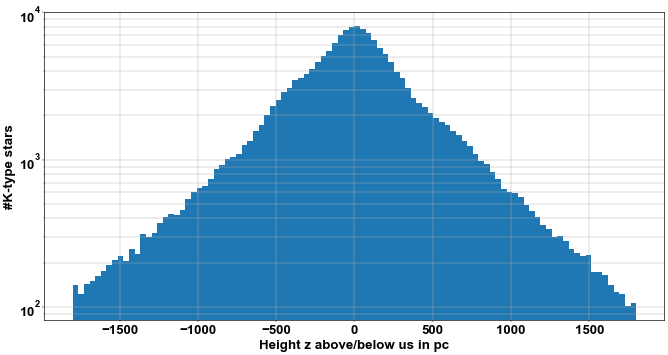

Requirement: Absolute magnitude between 6.724 and 7.4. Removes an additional 4.62e+05 sources
We are left with 1.79e+05 sources


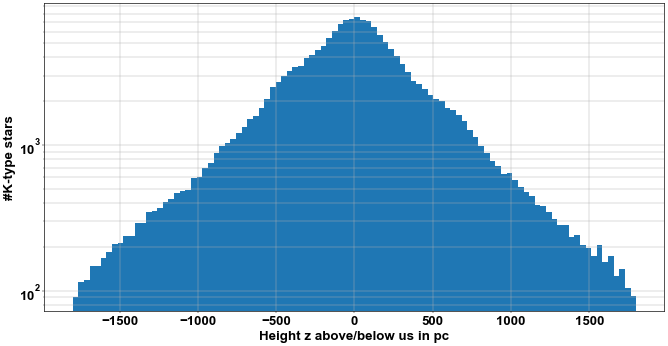

In [48]:
def Verarbeitung(am_min, am_max, n_bin, range, Plot):
    # Histogram in z
    tab_filtered = filtration(am_min, am_max)
    l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

    r_np = r_from_plx(parallax_np)
    z_np = r_np * np.sin(b_np*deg2rad) + 14.5 #correction for height of the sun above the galactic plane
    
    fig = plt.figure(figsize=(20,10))
    n, bins, _ = plt.hist(z_np, bins=n_bin, range=(-range, range))
    plt.yscale("log")
    plt.xlabel("Height z above/below us in pc")
    plt.ylabel("#K-type stars")
    plt.grid(which='both')
    fig.set_dpi(40)

    if Plot:
        plt.show()

    else:
        plt.close()

    # Create a text file
    np.savetxt(f'real data new intervals/n_{am_min*1000:.0f}{am_max*1000:.0f}.txt', n, fmt='%i')
    np.savetxt(f'real data new intervals/bins_{am_min*1000:.0f}{am_max*1000:.0f}.txt', bins, fmt='%f')

Verarbeitung(6.0, 6.724, 100, 1800, True)
Verarbeitung(6.724, 7.4, 100, 1800, True)


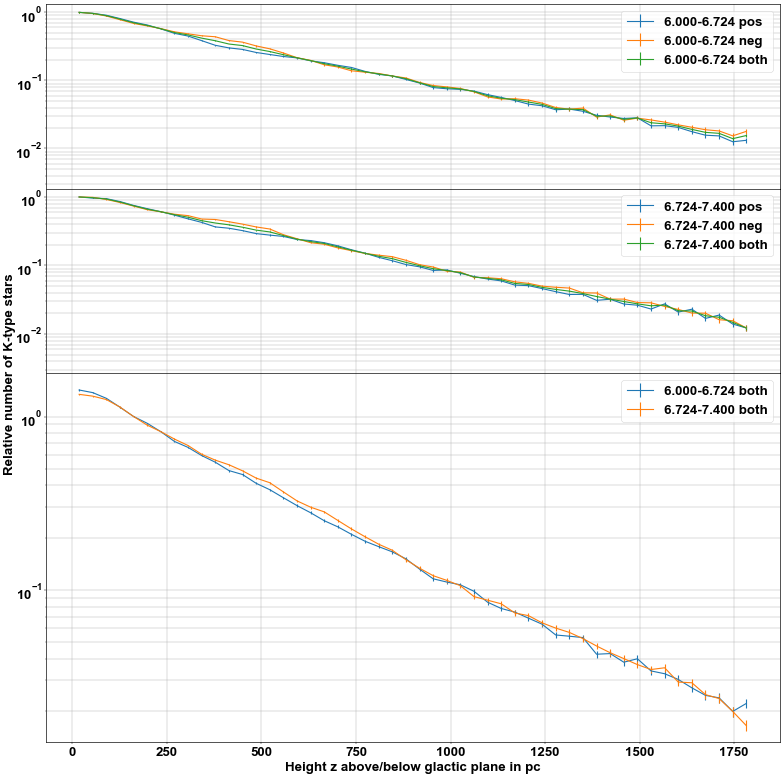

In [53]:
''' real data'''
n_real_1 = np.loadtxt('real data new intervals/n_60006724.txt')
bins_1 = np.loadtxt('real data new intervals/bins_60006724.txt')
zz_real_1 = (bins_1[1:]+bins_1[:-1])/2
pos_1 = np.where(zz_real_1 >= 0)
neg_1 = np.where(zz_real_1 < 0)
n_sum_1 = (n_real_1[pos_1]+np.flip(n_real_1[neg_1]))

n_real_2 = np.loadtxt('real data new intervals/n_67247400.txt')
bins_2 = np.loadtxt('real data new intervals/bins_67247400.txt')
zz_real_2 = (bins_2[1:]+bins_2[:-1])/2
pos_2 = np.where(zz_real_2 >= 0)
neg_2 = np.where(zz_real_2 < 0)
n_sum_2 = (n_real_2[pos_2]+np.flip(n_real_2[neg_2]))

''' visualisation'''
fig, ax = plt.subplots(3,1, figsize=(20,20), gridspec_kw={'height_ratios': [1, 1, 2]}, sharex=True)
ax[0].set_yscale("log")
ax[1].set_yscale("log")
ax[2].set_yscale("log")

ax[0].errorbar(zz_real_1[pos_1], n_real_1[pos_1]/n_real_1[pos_1][0], yerr=np.sqrt(n_real_1)[pos_1]/n_real_1[pos_1][0], label="6.000-6.724 pos")
ax[0].errorbar(abs(zz_real_1[neg_1]), n_real_1[neg_1]/n_real_1[neg_1][-1], yerr=np.sqrt(n_real_1)[neg_1]/n_real_1[neg_1][-1], label="6.000-6.724 neg")
ax[0].errorbar(zz_real_1[pos_1], n_sum_1/n_sum_1[0], yerr=np.sqrt(n_sum_1)/n_sum_1[0], label="6.000-6.724 both")

ax[1].errorbar(zz_real_2[pos_2], n_real_2[pos_2]/n_real_2[pos_2][0], yerr=np.sqrt(n_real_2)[pos_2]/n_real_2[pos_2][0], label="6.724-7.400 pos")
ax[1].errorbar(abs(zz_real_2[neg_2]), n_real_2[neg_2]/n_real_2[neg_2][-1], yerr=np.sqrt(n_real_2)[neg_2]/n_real_2[neg_2][-1], label="6.724-7.400 neg")
ax[1].errorbar(zz_real_2[pos_2], n_sum_2/n_sum_2[0], yerr=np.sqrt(n_sum_2)/n_sum_2[0], label="6.724-7.400 both")

ax[2].errorbar(zz_real_1[pos_1], n_sum_1/n_sum_1[4], yerr=np.sqrt(n_sum_1)/n_sum_1[4], label="6.000-6.724 both")
ax[2].errorbar(zz_real_2[pos_2], n_sum_2/n_sum_2[4], yerr=np.sqrt(n_sum_2)/n_sum_2[4], label="6.724-7.400 both")

ax[2].set_xlabel("Height z above/below glactic plane in pc")
ax[0].set_ylabel("Relative number of K-type stars")
ax[0].yaxis.set_label_coords(-0.04, -1)

ax[0].grid(which='both')
ax[0].legend()
ax[1].grid(which='both')
ax[1].legend()
ax[2].grid(which='both')
ax[2].legend()

plt.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.savefig("Plots/Height_distribution_real_data_comparison.png")
fig.set_dpi(40)
plt.show()
